# Function transformation


In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

directory = "/content/drive/MyDrive/data/"
path = os.listdir(directory)
file_path = path[-1]
file = os.path.join(directory, file_path)

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/data/car_price_dataset.csv")

In [4]:
df.head()

,car_age,mileage,engine_size,horsepower,brand_tier,accident_history,price
0,6.6,54143.0,2.20,122.1,1,0,30754
1,4.2,40356.0,3.44,209.1,0,0,56533
2,3.9,60283.0,1.04,60.0,2,0,17619
3,3.9,36784.0,2.95,170.8,0,0,32945
4,12.4,134914.0,3.01,170.1,1,0,56255


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_age           1000 non-null   float64
 1   mileage           985 non-null    float64
 2   engine_size       1000 non-null   float64
 3   horsepower        985 non-null    float64
 4   brand_tier        1000 non-null   int64  
 5   accident_history  1000 non-null   int64  
 6   price             1000 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 54.8 KB


In [6]:
df.describe()

,car_age,mileage,engine_size,horsepower,brand_tier,accident_history,price
count,1000.000000,985.000000,1000.000000,985.000000,1000.000000,1000.000000,1000.000000
mean,5.656600,62136.630457,2.499190,150.239289,0.630000,0.267000,55846.494000
std,3.672523,42965.736855,0.863536,53.258865,0.729131,0.442614,50942.554228
min,0.000000,500.000000,1.000000,60.000000,0.000000,0.000000,800.000000
25%,2.900000,31561.000000,1.770000,105.800000,0.000000,0.000000,19724.500000
50%,4.800000,51933.000000,2.450000,147.500000,0.000000,0.000000,41173.000000
75%,7.500000,82790.000000,3.260000,194.600000,1.000000,1.000000,73284.250000
max,20.000000,269757.000000,4.000000,265.100000,2.000000,1.000000,355973.000000


In [7]:
df.isnull().sum()

,0
car_age,0
mileage,15
engine_size,0
horsepower,15
brand_tier,0
accident_history,0
price,0


In [8]:
df["mileage"].corr(df["price"])

np.float64(-0.1696041534119584)

In [9]:
X = df.drop("price", axis=1)
Y = df["price"]

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [12]:
X_train.head()

,car_age,mileage,engine_size,horsepower,brand_tier,accident_history
29,9.3,113859.0,3.27,195.5,0,0
535,0.5,2924.0,2.29,131.6,1,0
695,4.8,70973.0,2.10,141.8,1,0
557,3.3,43716.0,2.73,143.0,0,0
836,2.2,12721.0,1.67,92.7,0,0


In [13]:
X_train.isnull().sum()

,0
car_age,0
mileage,13
engine_size,0
horsepower,14
brand_tier,0
accident_history,0


In [14]:
# fill missing using imputer
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="mean")
X_trained_imputed = imp.fit_transform(X_train)
X_test_imputed = imp.transform(X_test)

In [15]:
X_trained_imputed.shape

(800, 6)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_trained_imputed, y_train)

y_pred = model.predict(X_test_imputed)

In [17]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.8181151886744958

In [18]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(model, X_trained_imputed, y_train, cv=100, scoring="r2")

score.mean()

np.float64(0.711641218987328)

In [19]:
df

,car_age,mileage,engine_size,horsepower,brand_tier,accident_history,price
0,6.6,54143.0,2.20,122.1,1,0,30754
1,4.2,40356.0,3.44,209.1,0,0,56533
2,3.9,60283.0,1.04,60.0,2,0,17619
3,3.9,36784.0,2.95,170.8,0,0,32945
4,12.4,134914.0,3.01,170.1,1,0,56255
...,...,...,...,...,...,...,...
995,4.1,46047.0,2.40,110.4,1,0,44151
996,4.8,51938.0,1.32,88.3,0,1,10662
997,13.2,113486.0,2.95,168.6,2,0,96073
998,2.6,30164.0,3.60,207.4,2,0,163020


In [20]:
df.isnull().sum()

,0
car_age,0
mileage,15
engine_size,0
horsepower,15
brand_tier,0
accident_history,0
price,0


In [21]:
X = df.drop("price", axis=1)
Y = df["price"]

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='car_age', ylabel='Count'>

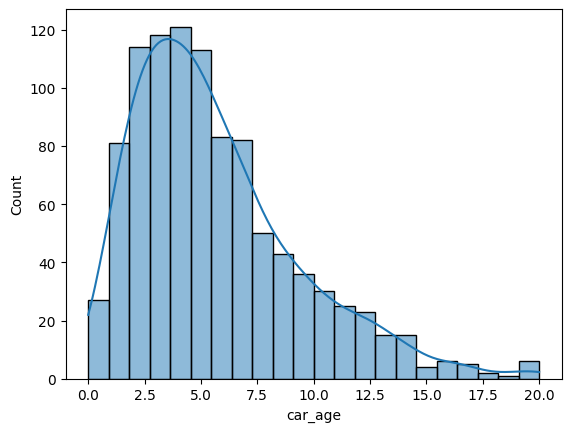

In [23]:
sns.histplot(df["car_age"], kde=True)

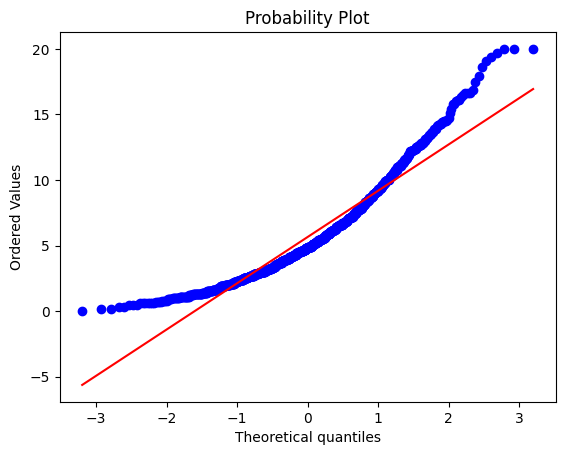

In [24]:
from scipy import stats
import matplotlib.pyplot as plt

stats.probplot(df["car_age"], dist="norm", plot=plt)
plt.show()

In [25]:
df.columns

Index(['car_age', 'mileage', 'engine_size', 'horsepower', 'brand_tier',
       'accident_history', 'price'],
      dtype='object')

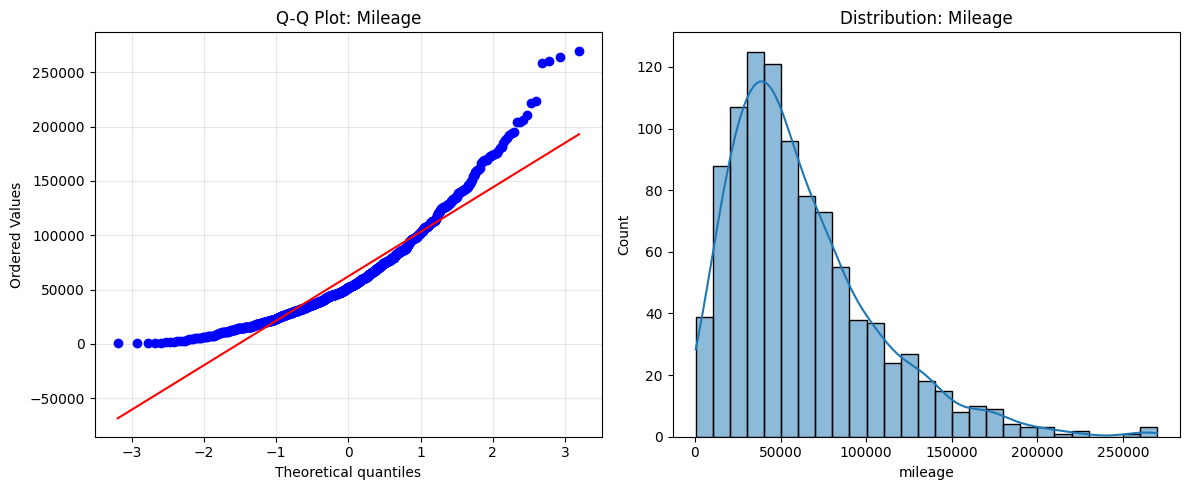

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
stats.probplot(df["mileage"].dropna(), dist="norm", plot=ax1)
ax1.set_title("Q-Q Plot: Mileage", fontsize=12)
ax1.grid(True, alpha=0.3)


sns.histplot(df["mileage"], kde=True, ax=ax2)
ax2.set_title("Distribution: Mileage", fontsize=12)

plt.tight_layout()
plt.show()

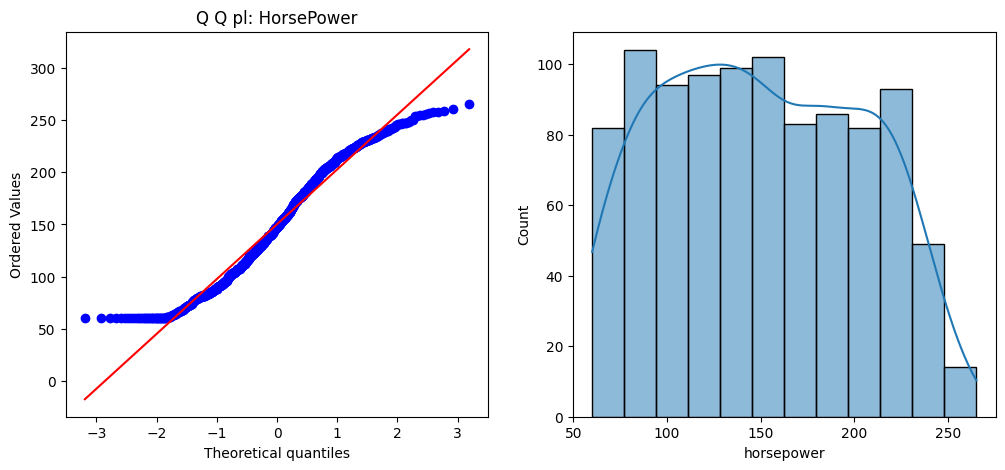

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(df["horsepower"].dropna(), dist="norm", plot=axes[0])
axes[0].set_title("Q Q pl: HorsePower", fontsize=12)


sns.histplot(df["horsepower"].dropna(), ax=axes[1], kde=True)

plt.show()

In [38]:
X.shape, X_train.shape, X_test.shape

((1000, 6), (800, 6), (200, 6))

In [ ]:
X["mileage"].isnull().sum()


np.int64(15)

In [70]:
X_filtered_train = X_train.dropna()
X_filtered_test = X_test.dropna()

In [72]:
X_filtered_train["mileage"].isnull().sum(), X_filtered_test["mileage"].isnull().sum()


(np.int64(0), np.int64(0))

In [73]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

mileage_train = X_filtered_train[["mileage"]]
mileage_test = X_filtered_test[["mileage"]]

X_train_mileage_imputed = imputer.fit_transform(mileage_train)
X_test_mileage_imputed = imputer.transform(mileage_test)

In [74]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(func=np.log10, validate=True)

X_train_mileage_loged = log_transformer.fit_transform(X_train_mileage_imputed)
X_test_mileage_loged = log_transformer.transform(X_test_mileage_imputed)

In [75]:
X_train_mileage_imputed

array([[113859.],
       [  2924.],
       [ 70973.],
       [ 43716.],
       [ 12721.],
       [119684.],
       [ 48606.],
       [ 46535.],
       [ 26471.],
       [ 40757.],
       [  5671.],
       [ 64370.],
       [ 14479.],
       [ 44256.],
       [ 47210.],
       [ 16960.],
       [ 97690.],
       [180991.],
       [ 20992.],
       [ 34852.],
       [ 39696.],
       [ 31565.],
       [ 77373.],
       [ 25456.],
       [ 60283.],
       [ 54517.],
       [169352.],
       [ 38668.],
       [ 26084.],
       [ 29894.],
       [ 20152.],
       [ 87303.],
       [ 98480.],
       [ 77380.],
       [ 37786.],
       [125479.],
       [ 73999.],
       [ 81777.],
       [ 36784.],
       [ 13171.],
       [ 65446.],
       [ 74194.],
       [ 91788.],
       [ 24627.],
       [136766.],
       [ 18099.],
       [157874.],
       [  8770.],
       [ 61078.],
       [ 79072.],
       [ 58937.],
       [ 69287.],
       [160899.],
       [ 53638.],
       [ 71954.],
       [20

In [ ]:

sns.histplot(X_train_mileage_imputed, kde=True)
plt.show()

SyntaxError: expected argument value expression (1833146283.py, line 1)